In [1]:
from src import Extractor

In [4]:
TABLE_NAME="works4cdp_assay"
SAMPLE_ID=24 #Concentrado final de courier cobre

db_config = {
    'user': 'myuser', 
    'password': 'mypassword', 
    'host': 'localhost', 
    'port': '5432', 
    'dbname': 'mydb'
}


In [8]:
datos = Extractor(table_name=TABLE_NAME, **db_config)
df_columnas = datos.get_head()
df_columnas

,column_name,data_type,is_nullable
0,id,bigint,NO
1,date,date,YES
2,time,time without time zone,YES
3,instance,integer,YES
4,n2cu,integer,YES
5,n1fe,integer,YES
6,n5ech5,integer,YES
7,n4mo,integer,YES
8,n3zn,integer,YES
9,n6sc,integer,YES


In [6]:
df_intensidad = datos.get_intensity(SAMPLE_ID)
df_intensidad.head()

,date,time,instance,n1fe,n2cu,n3zn,n4mo,n5ech5,n6sc,n7ech7
0,2025-12-03,11:01:00,1764777025,33558,38556,322,1690,None,1783,None
1,2025-12-01,11:04:20,1764604983,30953,34624,212,2667,None,1778,None
2,2025-12-01,11:01:46,1764604638,31900,35195,218,2587,None,1756,None
3,2025-11-28,12:29:52,1764349910,37782,39341,279,1812,None,1646,None
4,2025-11-26,11:11:58,1764173370,37364,42379,343,2409,None,1728,None


Información del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      468 non-null    object
 1   time      468 non-null    object
 2   instance  468 non-null    int64 
 3   n1fe      468 non-null    int64 
 4   n2cu      468 non-null    int64 
 5   n3zn      468 non-null    int64 
 6   n4mo      468 non-null    int64 
 7   n5ech5    0 non-null      object
 8   n6sc      468 non-null    int64 
 9   n7ech7    0 non-null      object
dtypes: int64(6), object(4)
memory usage: 36.7+ KB

Estadísticas Descriptivas:


,instance,n1fe,n2cu,n3zn,n4mo,n6sc
count,4.680000e+02,468.000000,468.000000,468.000000,468.000000,468.000000
mean,1.696638e+09,38843.995726,39760.091880,206.950855,2682.884615,1521.820513
std,4.111352e+07,4780.271318,3943.366165,85.247616,1245.328788,195.226026
min,1.625504e+09,3884.000000,7348.000000,123.000000,842.000000,1174.000000
25%,1.662050e+09,36109.250000,37853.250000,166.000000,1899.250000,1331.000000
50%,1.697559e+09,38854.000000,40004.000000,190.000000,2411.500000,1559.000000
75%,1.730002e+09,42161.750000,42324.000000,222.000000,3076.250000,1690.500000
max,1.767610e+09,49554.000000,48016.000000,1301.000000,10225.000000,2553.000000


Rango de fechas: 2021-07-05 12:02:23 a 2026-01-05 10:49:31


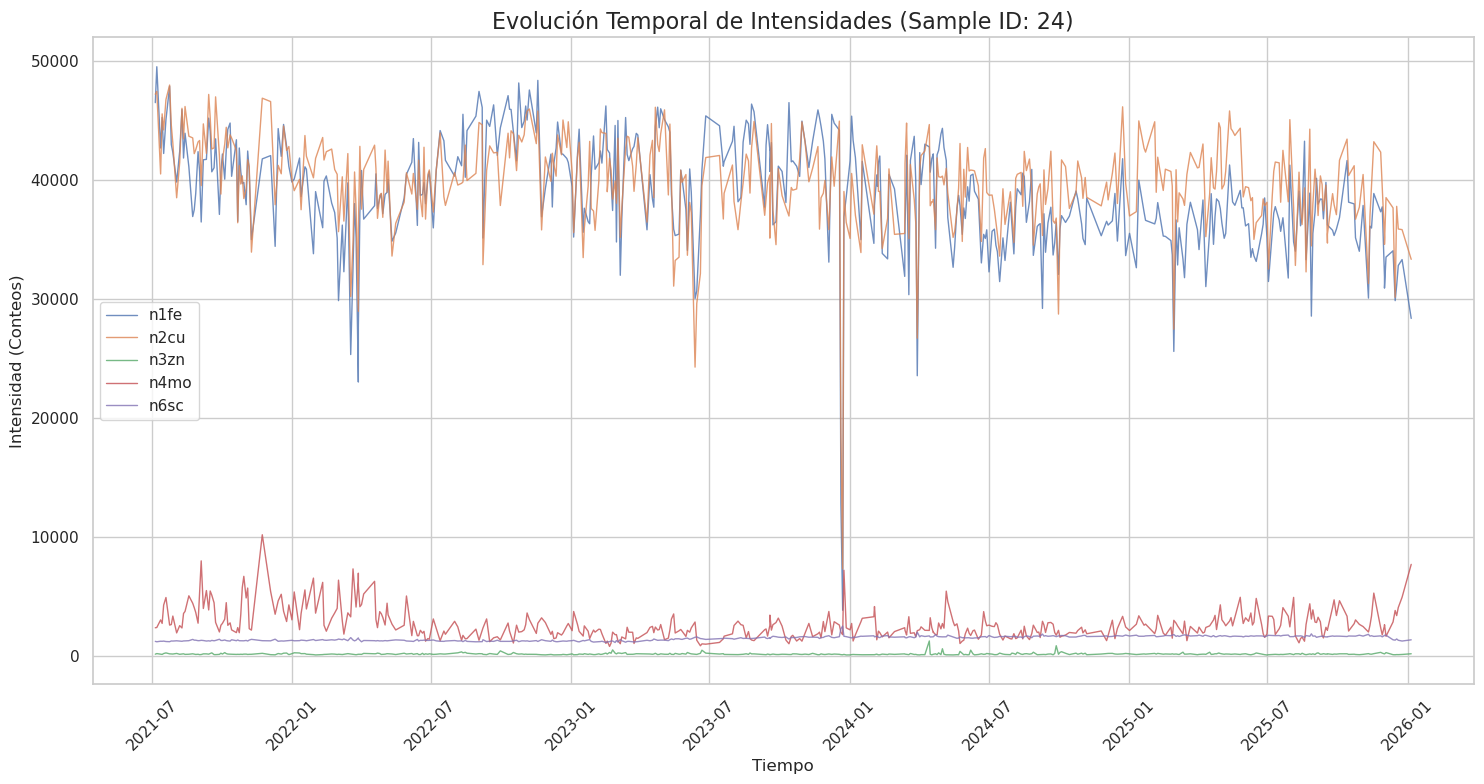

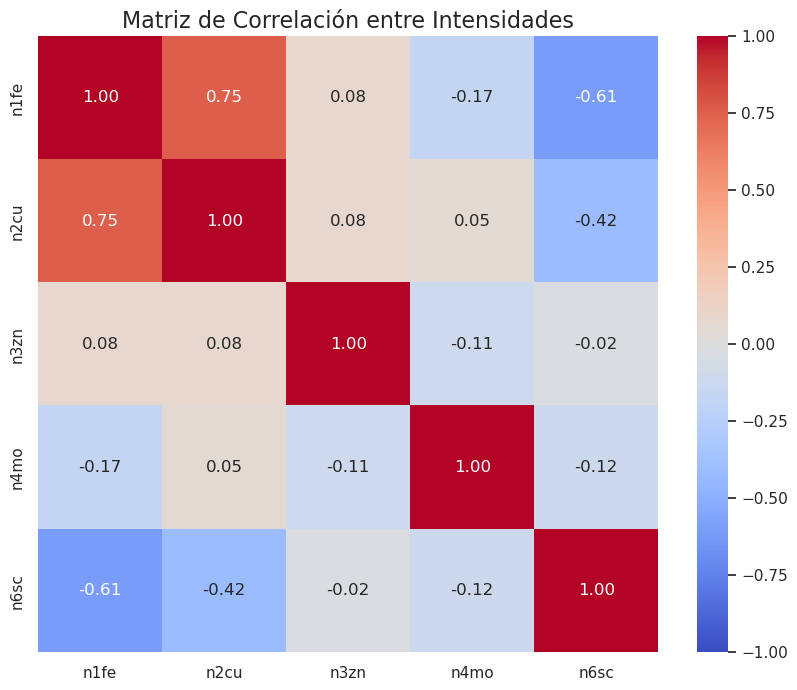

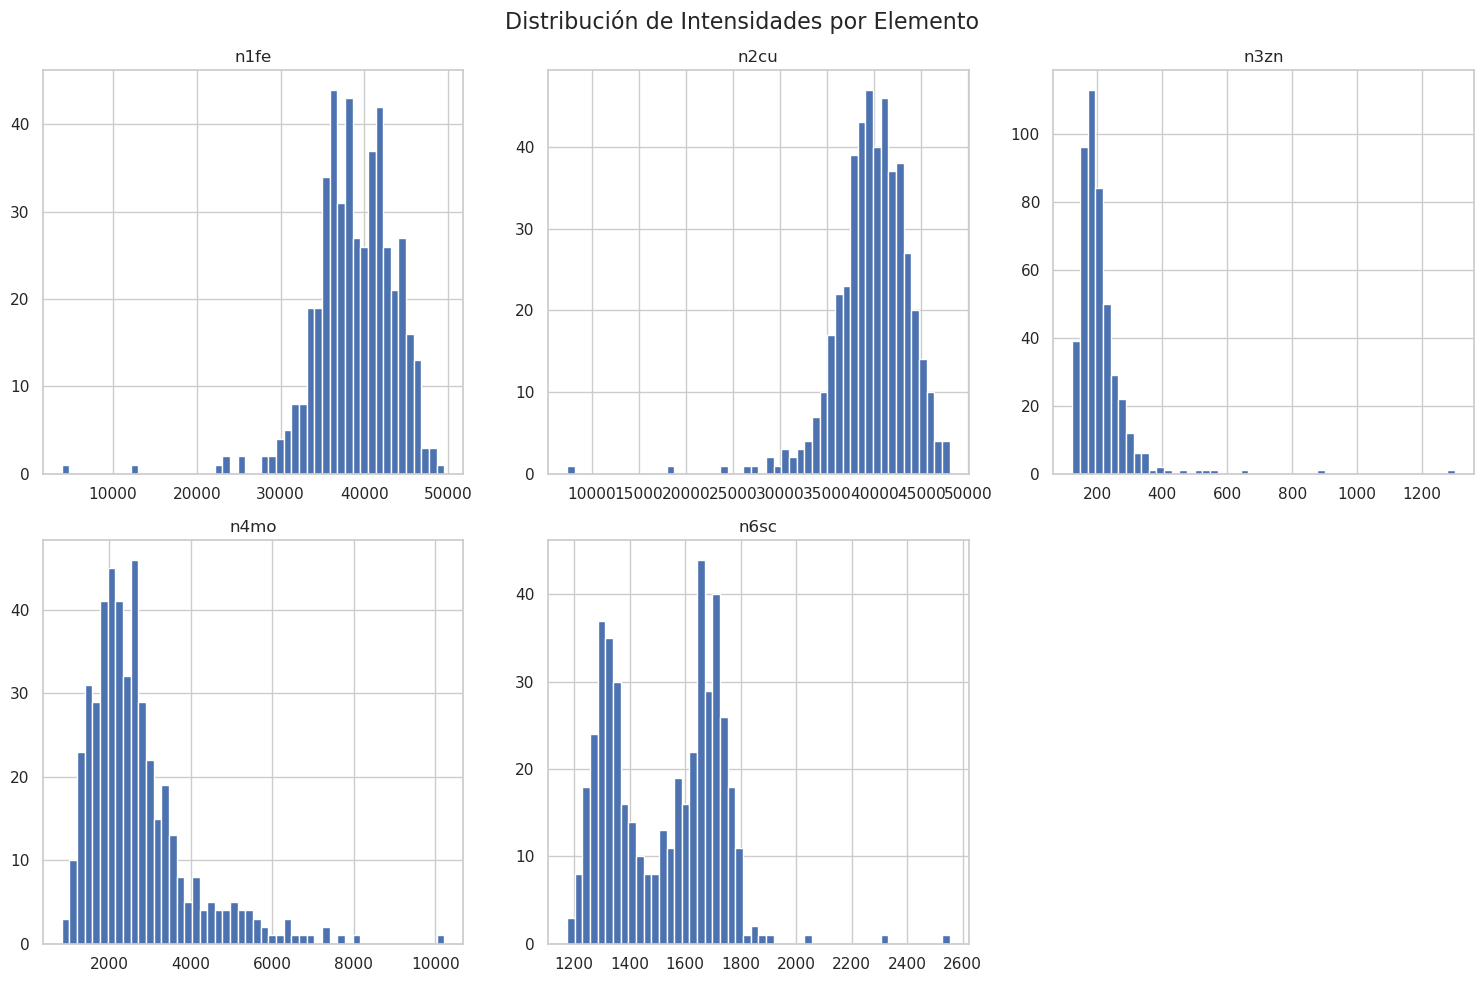

In [9]:
# Celdas sugeridas para continuar el análisis en el notebook

# ---------------------------------------------------------
# Célula 1: Importación de librerías para análisis y gráficos
# ---------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------------------------------------
# Célula 2: Información general y limpieza básica
# Verifica tipos de datos y valores nulos
# ---------------------------------------------------------
print("Información del DataFrame:")
df_intensidad.info()

print("\nEstadísticas Descriptivas:")
display(df_intensidad.describe())

# ---------------------------------------------------------
# Célula 3: Preprocesamiento de Fechas
# Crear un índice temporal combinando 'date' y 'time'
# ---------------------------------------------------------
# Convertir a string para asegurar concatenación correcta, luego a datetime
df_intensidad['datetime'] = pd.to_datetime(
    df_intensidad['date'].astype(str) + ' ' + df_intensidad['time'].astype(str)
)

# Ordenar por fecha y establecer como índice
df_intensidad = df_intensidad.sort_values('datetime')
df_intensidad.set_index('datetime', inplace=True)

print("Rango de fechas:", df_intensidad.index.min(), "a", df_intensidad.index.max())

# ---------------------------------------------------------
# Célula 4: Visualización de Series de Tiempo (Evolución de Intensidades)
# Graficar cómo varían los elementos principales en el tiempo
# ---------------------------------------------------------
elementos_cols = ['n1fe', 'n2cu', 'n3zn', 'n4mo', 'n6sc']

plt.figure(figsize=(15, 8))
for col in elementos_cols:
    if col in df_intensidad.columns:
        plt.plot(df_intensidad.index, df_intensidad[col], label=col, alpha=0.8, linewidth=1)

plt.title(f'Evolución Temporal de Intensidades (Sample ID: {SAMPLE_ID})', fontsize=16)
plt.xlabel('Tiempo')
plt.ylabel('Intensidad (Conteos)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Célula 5: Matriz de Correlación
# Ver qué elementos varían conjuntamente
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Calculamos correlación solo sobre las columnas numéricas de interés
corr_matrix = df_intensidad[elementos_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Intensidades', fontsize=16)
plt.show()

# ---------------------------------------------------------
# Célula 6: Distribución de las Intensidades (Histogramas)
# ---------------------------------------------------------
df_intensidad[elementos_cols].hist(bins=50, figsize=(15, 10), layout=(2, 3), grid=True)
plt.suptitle('Distribución de Intensidades por Elemento', fontsize=16)
plt.tight_layout()
plt.show()

Datos listos para clustering. Registros: 468, Características: 5


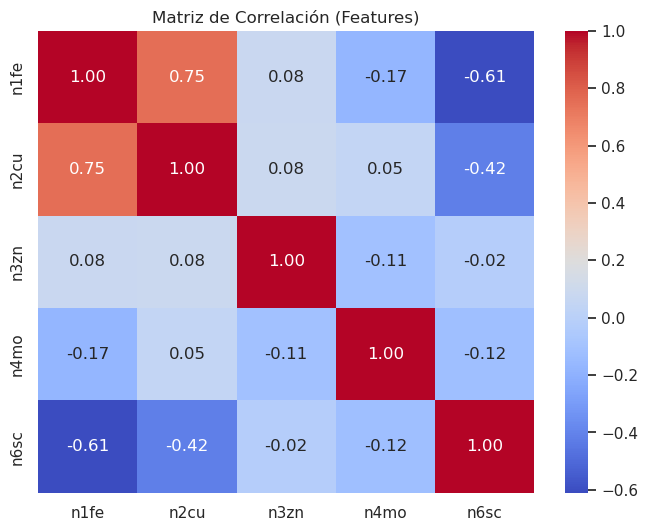

Varianza explicada por 2 componentes PCA: 67.12%


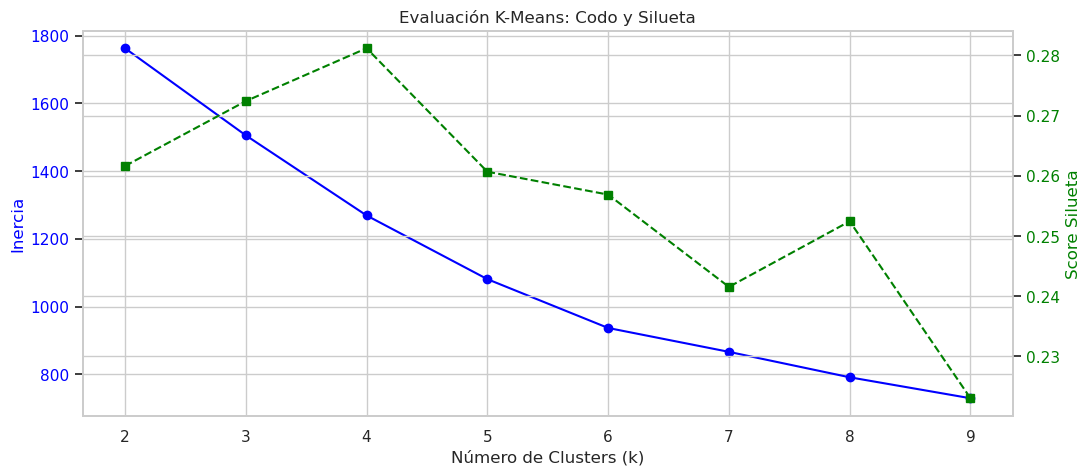

Mejor K sugerido por Silueta: 4


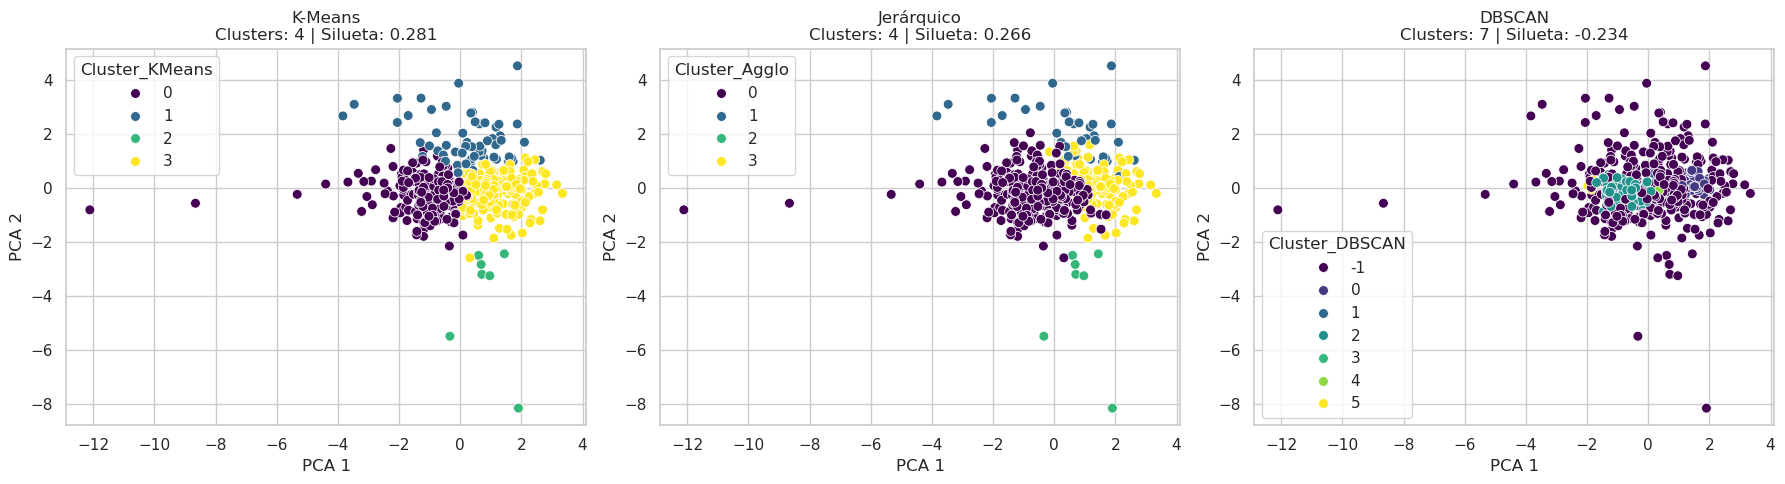


Nota sobre DBSCAN: Si ves muchos puntos como -1, son considerados 'ruido'. Ajusta 'eps' hacia arriba si es necesario.

Perfil Promedio de los Clusters (K-Means):


,n1fe,n2cu,n3zn,n4mo,n6sc
Cluster_KMeans,,,,,
0,35590.233010,37651.849515,197.412621,2416.145631,1671.378641
1,37908.354839,40535.983871,195.870968,5149.129032,1402.290323
2,40983.428571,39809.571429,702.428571,1855.857143,1518.285714
3,42539.896373,41759.295337,202.720207,2205.321244,1400.715026


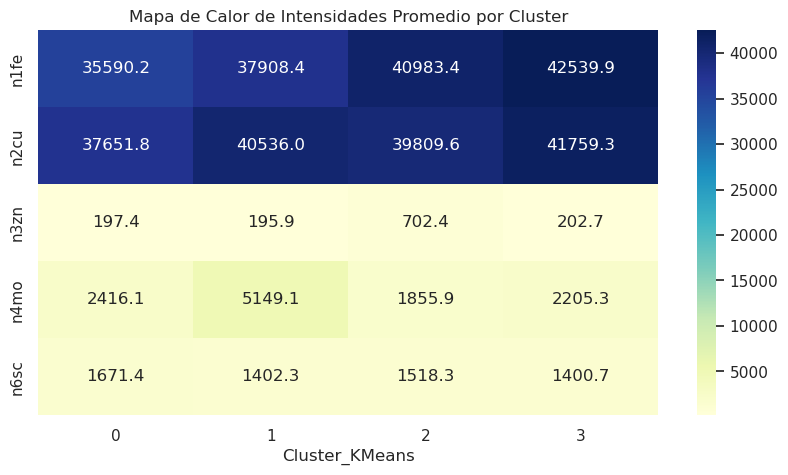

In [10]:
# ---------------------------------------------------------
# IMPORTACIÓN DE LIBRERÍAS
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ---------------------------------------------------------
# 1. PREPARACIÓN Y SELECCIÓN DE CARACTERÍSTICAS
# ---------------------------------------------------------
# Definimos las columnas de interés (elementos químicos/intensidades)
# Basado en tu dataframe anterior: n1fe, n2cu, n3zn, n4mo, n6sc
features = ['n1fe', 'n2cu', 'n3zn', 'n4mo', 'n6sc']

# Filtramos el dataframe para tener solo las columnas numéricas y eliminamos nulos
df_cluster = df_intensidad[features].dropna().copy()

# Estandarización (CRÍTICO para clustering ya que las escalas pueden variar)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Datos listos para clustering. Registros: {X_scaled.shape[0]}, Características: {X_scaled.shape[1]}")

# ---------------------------------------------------------
# 2. ANÁLISIS DE CORRELACIÓN Y PCA (Para visualizar)
# ---------------------------------------------------------
# Matriz de correlación para entender redundancia
plt.figure(figsize=(8, 6))
sns.heatmap(df_cluster.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación (Features)")
plt.show()

# Reducción de dimension a 2 componentes principales para visualizar los clusters luego
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada por 2 componentes PCA: {pca.explained_variance_ratio_.sum():.2%}")

# ---------------------------------------------------------
# 3. EVALUACIÓN DE MODELOS: K-MEANS (Método del Codo y Silueta)
# ---------------------------------------------------------
inertia = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráfico del Método del Codo y Silueta
fig, ax1 = plt.subplots(figsize=(12, 5))

# Eje Y1: Inercia (Codo)
ax1.plot(k_range, inertia, 'o-', color='blue', label='Inercia (Codo)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Evaluación K-Means: Codo y Silueta')

# Eje Y2: Silueta
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 's--', color='green', label='Score Silueta')
ax2.set_ylabel('Score Silueta', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.show()

# Seleccionamos el mejor K basado en silueta (puedes ajustar esto manualmente si prefieres)
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Mejor K sugerido por Silueta: {best_k}")

# ---------------------------------------------------------
# 4. IMPLEMENTACIÓN Y COMPARACIÓN DE OTROS MODELOS
# ---------------------------------------------------------

# A) K-Means con el mejor K
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_transform(X_scaled)
df_cluster['Cluster_KMeans'] = kmeans_final.labels_

# B) Diferente enfoque: Clustering Jerárquico (Aglomerativo)
agglo = AgglomerativeClustering(n_clusters=best_k)
df_cluster['Cluster_Agglo'] = agglo.fit_predict(X_scaled)

# C) Diferente enfoque: DBSCAN (Basado en densidad, detecta ruido)
# eps y min_samples requieren ajuste fino. Empezamos con valores comunes.
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_cluster['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# ---------------------------------------------------------
# 5. VISUALIZACIÓN DE RESULTADOS (Usando PCA)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [('K-Means', 'Cluster_KMeans'), 
           ('Jerárquico', 'Cluster_Agglo'), 
           ('DBSCAN', 'Cluster_DBSCAN')]

for i, (nombre, col_cluster) in enumerate(modelos):
    # Calculamos silueta solo si hay más de 1 cluster y menos que el total de datos (y quitando ruido -1 para DBSCAN si se quiere purista)
    n_clusters = len(set(df_cluster[col_cluster])) - (1 if -1 in df_cluster[col_cluster] else 0)
    
    score = "N/A"
    if 1 < n_clusters < len(df_cluster):
         score = silhouette_score(X_scaled, df_cluster[col_cluster])
    
    # Scatter plot sobre componentes PCA
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_cluster[col_cluster], 
                    palette='viridis', ax=axes[i], s=50, legend='full')
    axes[i].set_title(f'{nombre}\nClusters: {n_clusters} | Silueta: {score:.3f}')
    axes[i].set_xlabel('PCA 1')
    axes[i].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

print("\nNota sobre DBSCAN: Si ves muchos puntos como -1, son considerados 'ruido'. Ajusta 'eps' hacia arriba si es necesario.")

# ---------------------------------------------------------
# 6. ANÁLISIS DE LOS GRUPOS (PERFILAMIENTO)
# ---------------------------------------------------------
# Usamos el mejor modelo (por defecto KMeans aquí) para ver las características promedio
numeric_cols = features + ['Cluster_KMeans']
perfil = df_cluster[numeric_cols].groupby('Cluster_KMeans').mean()

print("\nPerfil Promedio de los Clusters (K-Means):")
display(perfil)

# Visualización del perfil (Parallel Coordinates o Heatmap)
plt.figure(figsize=(10, 5))
sns.heatmap(perfil.T, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title('Mapa de Calor de Intensidades Promedio por Cluster')
plt.show()